# Причины уменьшения конверсии

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel(r"C:\Users\NyaxyS\Downloads\dannye-ce1e2d0f-249c-4782-a612-f0d6eeba56c0.xlsx")

In [7]:
df.tail()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
52,27.02.2025,Неделя 8,209,133,68,57,44,39
53,28.02.2025,Неделя 8,205,144,74,63,52,48
54,01.03.2025,Неделя 8,199,137,66,56,46,42
55,02.03.2025,Неделя 8,234,152,77,58,48,44
56,ИТОГО,Нед. 1–8,11557,7745,5131,4116,3218,2823


In [ ]:
df = df.drop(56)
df.tail()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
51,26.02.2025,Неделя 8,212,149,76,64,53,45
52,27.02.2025,Неделя 8,209,133,68,57,44,39
53,28.02.2025,Неделя 8,205,144,74,63,52,48
54,01.03.2025,Неделя 8,199,137,66,56,46,42
55,02.03.2025,Неделя 8,234,152,77,58,48,44


In [ ]:
df['Неделя'] = pd.to_numeric(df['Неделя'].str.slice(7,8))


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Дата              56 non-null     object
 1   Неделя            56 non-null     int64 
 2   Установки         56 non-null     int64 
 3   Регистрации       56 non-null     int64 
 4   Открыли поиск     56 non-null     int64 
 5   Просмотрели авто  56 non-null     int64 
 6   Забронировали     56 non-null     int64 
 7   Первая поездка    56 non-null     int64 
dtypes: int64(7), object(1)
memory usage: 3.6+ KB


In [34]:
df.describe()

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
count,56.000000,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,4.500000,206.37500,138.303571,91.625000,73.500000,57.464286,50.410714
std,2.312024,14.39768,10.560509,13.054519,10.493288,8.351297,7.248264
min,1.000000,181.00000,117.000000,64.000000,53.000000,42.000000,36.000000
25%,2.750000,195.50000,131.750000,82.750000,65.750000,52.000000,45.750000
50%,4.500000,206.50000,138.500000,94.000000,74.000000,58.000000,51.000000
75%,6.250000,215.25000,146.250000,98.750000,81.000000,62.000000,55.000000
max,8.000000,238.00000,161.000000,117.000000,99.000000,82.000000,69.000000


In [35]:
df.head()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,1,206,130,91,70,57,51
1,07.01.2025,1,216,138,98,73,55,48
2,08.01.2025,1,181,117,86,69,52,46
3,09.01.2025,1,212,134,101,83,64,54
4,10.01.2025,1,218,143,97,73,60,53


In [37]:
df['Дата'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y')
df.dtypes

Дата                datetime64[ns]
Неделя                       int64
Установки                    int64
Регистрации                  int64
Открыли поиск                int64
Просмотрели авто             int64
Забронировали                int64
Первая поездка               int64
dtype: object

In [85]:
df['День недели'] = df['Дата'].dt.day_of_week

In [40]:
df['Выходной'] = df['День недели'].isin([5,6]).astype(int)

In [42]:
df.head(8)

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,День недели,Выходной
0,2025-01-06,1,206,130,91,70,57,51,0,0
1,2025-01-07,1,216,138,98,73,55,48,1,0
2,2025-01-08,1,181,117,86,69,52,46,2,0
3,2025-01-09,1,212,134,101,83,64,54,3,0
4,2025-01-10,1,218,143,97,73,60,53,4,0
5,2025-01-11,1,212,146,106,90,70,62,5,1
6,2025-01-12,1,213,145,110,89,72,60,6,1
7,2025-01-13,2,189,123,83,64,48,41,0,0


In [50]:
df.groupby('Неделя')[df.columns[2:8]].mean().round()

,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
Неделя,,,,,,
1,208.0,136.0,98.0,78.0,61.0,53.0
2,202.0,133.0,94.0,75.0,59.0,53.0
3,205.0,139.0,103.0,83.0,63.0,54.0
4,201.0,137.0,98.0,78.0,59.0,52.0
5,205.0,137.0,99.0,79.0,63.0,55.0
6,194.0,132.0,93.0,74.0,59.0,53.0
7,218.0,146.0,72.0,61.0,48.0,40.0
8,218.0,147.0,74.0,60.0,48.0,43.0


In [52]:
df.drop(columns='День недели', inplace=True)

### Проверим связь между выходными и будними


In [54]:
df.groupby('Выходной')[df.columns[2:8]].mean()

,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
Выходной,,,,,,
0,205.825,137.825,91.0000,72.9750,56.75,49.7500
1,207.750,139.500,93.1875,74.8125,59.25,52.0625


### Построим график для каждого значения в среднем по неделе

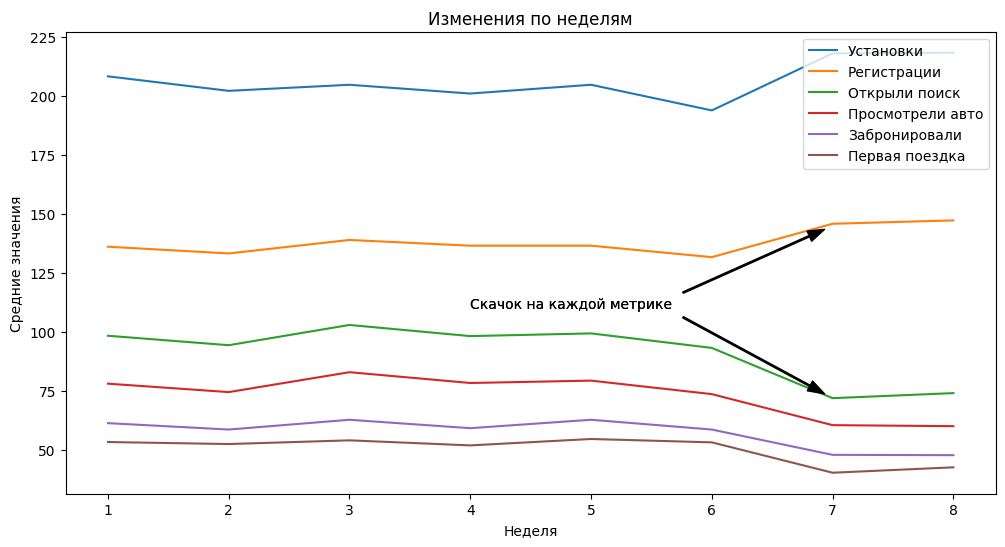

In [84]:
fig, ax = plt.subplots(figsize=(12, 6))
df.groupby('Неделя')[df.columns[2:8]].mean().plot(ax=ax)
plt.annotate('Скачок на каждой метрике', xy = (7, 145),  xytext=(4, 110),  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))
plt.annotate('Скачок на каждой метрике',xy = (7, 72),  xytext=(4, 110),  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))
plt.ylabel('Средние значения')
plt.title('Изменения по неделям')
plt.show()


In [86]:
df[df['Неделя'] == 7].groupby('День недели').mean()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,Выходной
День недели,,,,,,,,,
0,2025-02-17,7.0,201.0,134.0,70.0,60.0,45.0,38.0,0.0
1,2025-02-18,7.0,210.0,148.0,76.0,64.0,50.0,42.0,0.0
2,2025-02-19,7.0,235.0,161.0,80.0,68.0,55.0,46.0,0.0
3,2025-02-20,7.0,234.0,153.0,77.0,65.0,49.0,41.0,0.0
4,2025-02-21,7.0,203.0,137.0,65.0,53.0,43.0,36.0,0.0
5,2025-02-22,7.0,226.0,147.0,72.0,61.0,51.0,43.0,1.0
6,2025-02-23,7.0,217.0,141.0,64.0,53.0,43.0,37.0,1.0


In [87]:
df[df['Неделя'] == 6].groupby('День недели').mean()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,Выходной
День недели,,,,,,,,,
0,2025-02-10,6.0,191.0,132.0,94.0,74.0,62.0,58.0,0.0
1,2025-02-11,6.0,202.0,139.0,95.0,74.0,62.0,55.0,0.0
2,2025-02-12,6.0,202.0,139.0,94.0,76.0,60.0,55.0,0.0
3,2025-02-13,6.0,186.0,132.0,89.0,68.0,54.0,49.0,0.0
4,2025-02-14,6.0,189.0,121.0,92.0,71.0,57.0,51.0,0.0
5,2025-02-15,6.0,197.0,133.0,96.0,81.0,61.0,55.0,1.0
6,2025-02-16,6.0,190.0,126.0,93.0,72.0,55.0,50.0,1.0


In [ ]:
week_conv = df.groupby('Неделя').agg(total_appload = ('Установки', 'sum'), total_registr = ('Регистрации', 'sum'), total_search = ('Открыли поиск', 'sum'), total_check = ('Просмотрели авто', 'sum'), total_book = ('Забронировали', 'sum'), total_try = ('Первая поездка', 'sum'))
week_conv

,total_appload,total_reg,total_search,total_check,total_book,total_try
Неделя,,,,,,
1,1458,953,689,547,430,374
2,1415,933,661,522,411,368
3,1433,973,721,581,440,379
4,1407,956,688,549,415,364
5,1433,956,696,556,440,383
6,1357,922,653,516,411,373
7,1526,1021,504,424,336,283
8,1528,1031,519,421,335,299


In [117]:
week_conv_first = week_conv['total_search']/week_conv['total_reg'] * 100
week_conv_first

Неделя
1    72.298006
2    70.846731
3    74.100719
4    71.966527
5    72.803347
6    70.824295
7    49.363369
8    50.339476
dtype: float64

In [107]:
week_conv_second = week_conv['total_check']/week_conv['total_search'] * 100
week_conv_second

Неделя
1    79.390421
2    78.971256
3    80.582524
4    79.796512
5    79.885057
6    79.019908
7    84.126984
8    81.117534
dtype: float64

In [112]:
week_conv_prefirst = week_conv['total_reg']/week_conv['total_appload']* 100

In [110]:
week_conv_third = week_conv['total_book']/week_conv['total_check'] * 100
week_conv_third

Неделя
1    78.610603
2    78.735632
3    75.731497
4    75.591985
5    79.136691
6    79.651163
7    79.245283
8    79.572447
dtype: float64

In [100]:
week_conv_fourth = week_conv['total_try']/week_conv['total_book'] * 100
week_conv_fourth

Неделя
1    86.976744
2    89.537713
3    86.136364
4    87.710843
5    87.045455
6    90.754258
7    84.226190
8    89.253731
dtype: float64

### Построим график динамики конверсии на каждом этапе

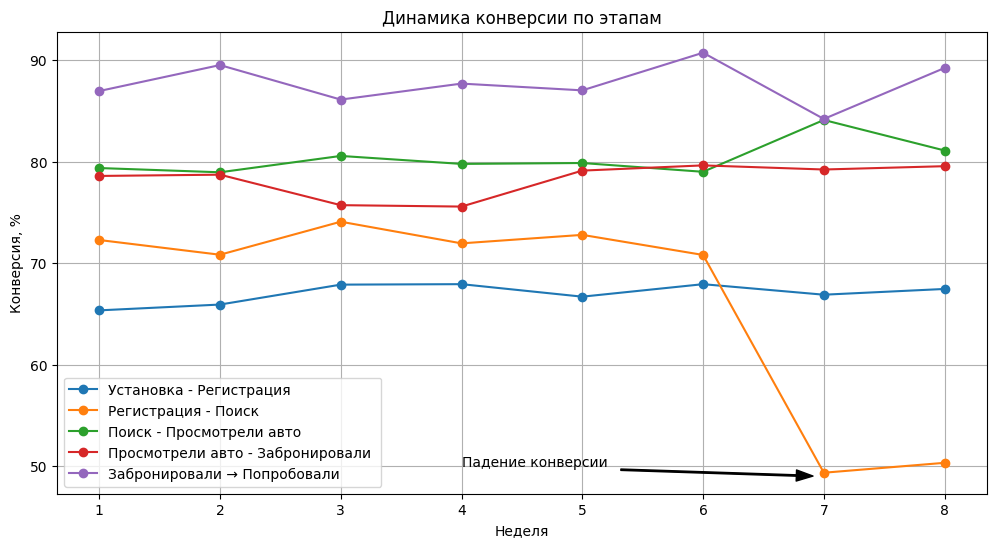

In [116]:
plt.figure(figsize=(12, 6))
plt.plot(week_conv.index, week_conv_prefirst, 'o-', label='Установка - Регистрация ')
plt.plot(week_conv.index, week_conv_first, 'o-', label='Регистрация - Поиск')
plt.plot(week_conv.index, week_conv_second, 'o-', label='Поиск - Просмотрели авто ')
plt.plot(week_conv.index, week_conv_third, 'o-', label='Просмотрели авто - Забронировали ')
plt.plot(week_conv.index, week_conv_fourth, 'o-', label='Забронировали → Попробовали')
plt.annotate('Падение конверсии', xy=(7,49), xytext=(4,50), arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))
plt.xlabel('Неделя')
plt.ylabel('Конверсия, %')
plt.title('Динамика конверсии по этапам')
plt.legend()
plt.grid(True)
plt.xticks(week_conv.index)
plt.show()